In [1]:
! pip install folium

## Importation et mise en forme

In [2]:
import s3fs
import geopandas as gpd
from pyproj import CRS
import matplotlib.pyplot as plt
import pandas as pd
import folium
import numpy as np
import math
from shapely.geometry import box

from astrovision.data import SatelliteImage
from astrovision.plot import make_mosaic

from clean_predictions import intersects_on_lines
from image_utils import find_image_of_point, find_images_of_bb

In [3]:
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"})
out = fs.download(rpath="projet-slums-detection/ilots", lpath="ilots", recursive=True)
out = fs.download(
    rpath="projet-slums-detection/data-prediction/PLEIADES/MAYOTTE",
    lpath="pred_mayotte",
    recursive=True,
)

In [4]:
pred_2020 = gpd.read_file("pred_mayotte/2020/test/15/predictions.gpkg")
pred_2023 = gpd.read_file("pred_mayotte/2023/test/15/predictions.gpkg")
ilots = gpd.read_file("ilots/ilots.gpkg")

#### Zones spécifiques de Mayotte

In [5]:
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"})

list_images_mayotte_2020 = [
    filename["Key"]
    for filename in fs.listdir("projet-slums-detection/data-raw/PLEIADES/MAYOTTE/2020/")
]

In [6]:
point = (-12.783007, 45.221377)
image_path = find_image_of_point(point, list_images_mayotte_2020, 4471, True)
filename = image_path.split(".")[0]
split_filename = filename.split("_")

left = float(split_filename[2]) * 1000 - 500.0
top = float(split_filename[3]) * 1000 + 500.0
right = left + 1000.0
bottom = top - 1000.0

# left, bottom, right, top = (523500.0, 8586500.0, 524500.0, 8587500.0)
bounding_box = box(left, bottom, right, top)

In [7]:
def big_image_of_bbox(bounding_box, departement, annee, fs):
    list_images = [
        filename["Key"]
        for filename in fs.listdir(
            f"projet-slums-detection/data-raw/PLEIADES/{departement}/{annee}/"
        )
    ]
    images_in_bb = find_images_of_bb(bounding_box, list_images)
    si_in_bb = []
    for filename in images_in_bb:
        si = SatelliteImage.from_raster(
            file_path=f"/vsis3/projet-slums-detection/data-raw/PLEIADES/{departement}/{annee}/{filename}",
            n_bands=int(3),
        )
        si_in_bb.append(si)

    big_si = make_mosaic(si_in_bb, bands_indices=[0, 1, 2])

    return big_si

In [8]:
big_si = big_image_of_bbox(bounding_box, "MAYOTTE", "2020", fs)

/opt/mamba/lib/python3.11/site-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [9]:
filtered_predictions_2020 = pred_2020[pred_2020.within(bounding_box)]
filtered_predictions_2023 = pred_2023[pred_2023.within(bounding_box)]

filtered_predictions_2020.reset_index(drop=True, inplace=True)
filtered_predictions_2023.reset_index(drop=True, inplace=True)

In [10]:
def plot_poly_in_zone(gdf, bounding_box):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Afficher les polygones filtrés
    gdf.plot(ax=ax, color="#ffaf70", edgecolor="black")

    left, bottom, right, top = bounding_box.bounds

    # Configurer les limites de l'axe pour se concentrer sur la bounding box
    ax.set_xlim(left, right)
    ax.set_ylim(bottom, top)

    # Enlever les axes pour une vue plus propre
    ax.set_axis_off()

    return plt.show()

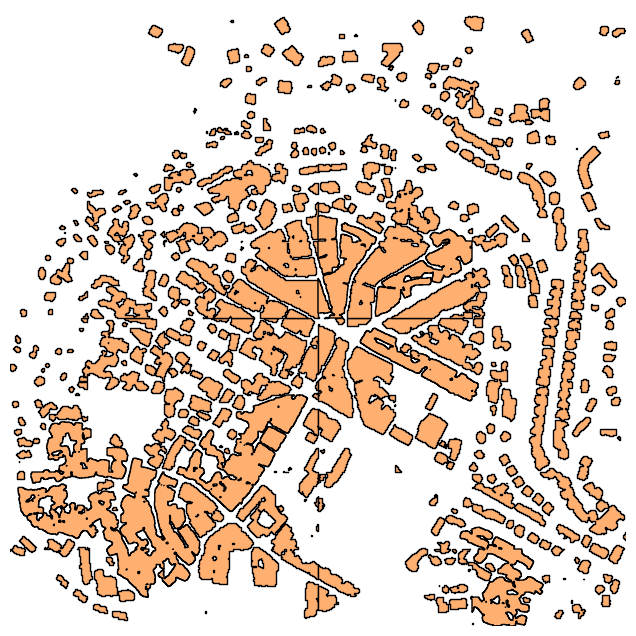

In [11]:
plot_poly_in_zone(filtered_predictions_2020, bounding_box)

In [12]:
def plot_poly_in_si_in_bbox(gdf, bounding_box, big_si):
    left, bottom, right, top = big_si.bounds

    fig, ax = plt.subplots()
    plt.imshow(
        np.transpose(big_si.array, (1, 2, 0))[:, :, [0, 1, 2]], extent=[left, right, bottom, top]
    )

    gdf.plot(ax=ax, facecolor="none", edgecolor="red")

    left_bb, bottom_bb, right_bb, top_bb = bounding_box.bounds
    ax.set_xlim(left_bb, right_bb)
    ax.set_ylim(bottom_bb, top_bb)

    plt.xticks([])
    plt.yticks([])
    return plt.show()

In [15]:
# point = (-12.768023, 45.190708)
# image_path = find_image_of_point(point, list_images_mayotte_2020, 4471, True)
# filename = image_path.split(".")[0]
# split_filename = filename.split("_")

# left = float(split_filename[2]) * 1000
# top = float(split_filename[3]) * 1000
# right = left + 1000.0 + 2000.0
# bottom = top - 1000.0 - 2000.0

# bounding_box = box(left, bottom, right, top)

In [13]:
filtered_predictions_2020 = pred_2020[pred_2020.within(bounding_box)]
filtered_predictions_2023 = pred_2023[pred_2023.within(bounding_box)]

filtered_predictions_2020.reset_index(drop=True, inplace=True)
filtered_predictions_2023.reset_index(drop=True, inplace=True)

In [14]:
filtered_predictions_2020_more = filtered_predictions_2020[
    filtered_predictions_2020.geometry.area > 10
]

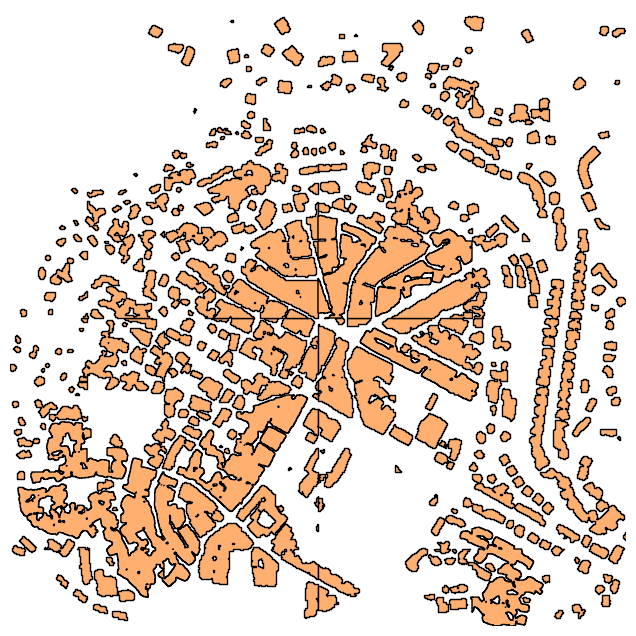

In [16]:
plot_poly_in_zone(filtered_predictions_2020_more, bounding_box)

In [19]:
def afficher_carte_interactive(gdf):
    gdf["area"] = gdf.area
    gdf = gdf.to_crs(epsg=3857)
    center = gdf.geometry.centroid.iloc[0]

    center_gdf = gpd.GeoDataFrame(index=[0], crs="epsg:3857", geometry=[center])
    center_gdf = center_gdf.to_crs(epsg=4326)
    center_point = center_gdf.geometry.iloc[0]

    m = folium.Map(location=[center_point.y, center_point.x], zoom_start=12)
    gdf = gdf.to_crs(epsg=4326)
    for index, row in gdf.iterrows():
        folium.GeoJson(
            row["geometry"], style_function=lambda x: {"color": "red"}, tooltip=row["area"]
        ).add_to(m)

    return m

In [ ]:
afficher_carte_interactive(filtered_predictions_2020)

In [21]:
filtered_predictions_2020.area.describe()

count     83.000000
mean      80.584337
std       86.701991
min        0.250000
25%       10.500000
50%       50.500000
75%      110.625000
max      371.500000
dtype: float64

Processing geometries: 100%|██████████| 477/477 [00:00<00:00, 3225.03it/s]
/opt/mamba/lib/python3.11/site-packages/geopandas/array.py:1459: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as RGM04 / UTM zone 38S (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


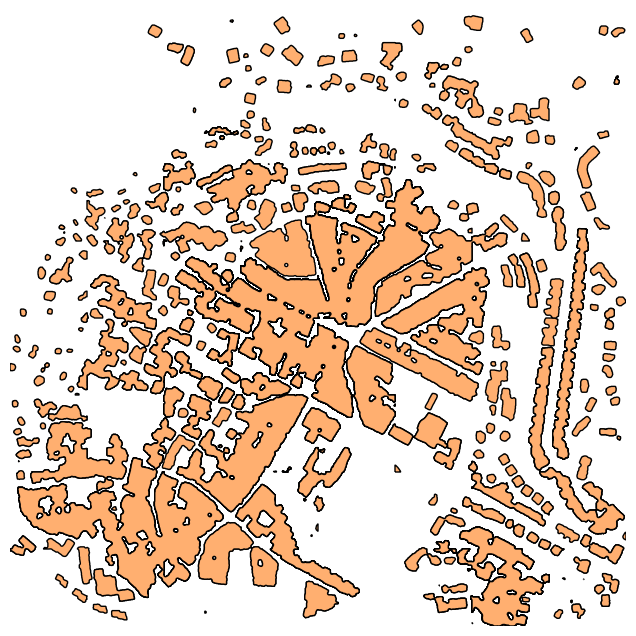

In [17]:
filtered_predictions_2020_copy = intersects_on_lines(filtered_predictions_2020.copy(), 2.5)
plot_poly_in_zone(filtered_predictions_2020_copy, bounding_box)

#### Mayotte entière

In [ ]:
pred_2020_copy = intersects_on_lines(pred_2020.copy())
pred_2023_copy = intersects_on_lines(pred_2023.copy())

In [ ]:
tgt_crs = CRS.from_epsg(4471)  # mayotte

pred_2020 = pred_2020.to_crs(tgt_crs)
pred_2023 = pred_2023.to_crs(tgt_crs)

pred_2020["area"] = pred_2020.area
pred_2023["area"] = pred_2023.area

ilots = ilots.to_crs(tgt_crs)
ilotsMayotte = ilots[ilots["ident_ilot"].str.startswith("976")]
ilotsMayotte["area"] = ilotsMayotte.geometry.area

pred_2020 = pred_2020.rename(columns={"area": "aire_bati"})
pred_2023 = pred_2023.rename(columns={"area": "aire_bati"})

In [ ]:
intersection_2020 = gpd.overlay(pred_2020, ilotsMayotte, how="intersection")
intersection_2023 = gpd.overlay(pred_2023, ilotsMayotte, how="intersection")

In [ ]:
filtered_gdf = intersection_2020[intersection_2020["ident_ilot"] == "976160204"]

fig, ax = plt.subplots(figsize=(8, 8))

ilotsMayotte[ilotsMayotte["ident_ilot"] == "976160204"].plot(ax=ax, color=None, edgecolor="red")
filtered_gdf.plot(ax=ax, color="#ffaf70", edgecolor="black")

ax.set_axis_off()
plt.show()

In [ ]:
area_per_ilot_2020 = intersection_2020.groupby("ident_ilot")["aire_bati"].sum()
area_per_ilot_2020.describe()

In [ ]:
area_per_ilot_2020

In [ ]:
area_per_ilot_2023 = intersection_2023.groupby("ident_ilot")["aire_bati"].sum()
area_per_ilot_2023.describe()

In [ ]:
tgt_crs = CRS.from_epsg(4471)  # mayotte

pred_2020_copy = pred_2020_copy.to_crs(tgt_crs)
pred_2023_copy = pred_2023_copy.to_crs(tgt_crs)

pred_2020_copy["area"] = pred_2020_copy.area
pred_2023_copy["area"] = pred_2023_copy.area

pred_2020_copy = pred_2020_copy.rename(columns={"area": "aire_bati"})
pred_2023_copy = pred_2023_copy.rename(columns={"area": "aire_bati"})

intersection_2020_copy = gpd.overlay(pred_2020_copy, ilotsMayotte, how="intersection")
intersection_2023_copy = gpd.overlay(pred_2023_copy, ilotsMayotte, how="intersection")

In [ ]:
area_per_ilot_2020_copy = intersection_2020_copy.groupby("ident_ilot")["aire_bati"].sum()
area_per_ilot_2020_copy.describe()

In [ ]:
area_per_ilot_2023_copy = intersection_2023_copy.groupby("ident_ilot")["aire_bati"].sum()
area_per_ilot_2023_copy.describe()

In [ ]:
intersection_2020["aire_bati_par_ilot"] = intersection_2020.groupby("ident_ilot")[
    "aire_bati"
].transform("sum")
intersection_2020

In [ ]:
filtered_gdf = intersection_2020_copy[intersection_2020_copy["ident_ilot"] == "976160204"]

fig, ax = plt.subplots(figsize=(8, 8))

ilotsMayotte[ilotsMayotte["ident_ilot"] == "976160204"].plot(ax=ax, color=None, edgecolor="red")
filtered_gdf.plot(ax=ax, color="#ffaf70", edgecolor="black")

ax.set_axis_off()
plt.show()

## Traitement des suppressions et ajouts

In [ ]:
sym_diff = gpd.overlay(pred_2020, pred_2023, how="symmetric_difference")
index = pd.RangeIndex(stop=len(sym_diff))
sym_diff = gpd.GeoDataFrame(sym_diff, crs="EPSG:4471", index=index)

polygones_commun = gpd.overlay(pred_2020, pred_2023, how="intersection")
resultat = sym_diff[~sym_diff.geometry.isin(polygones_commun.geometry)]

In [ ]:
resultat_2020 = gpd.sjoin(resultat, pred_2020, how="left", op="within")
suppression = resultat_2020[resultat_2020.index_right.isna()]
suppression = suppression.loc[:, resultat.columns]
# suppression = suppression.drop('area_1', axis=1)

resultat_2023 = gpd.sjoin(resultat, pred_2023, how="left", op="within")
creation = resultat_2023[resultat_2023.index_right.isna()]
creation = creation.loc[:, resultat.columns]
# creation = creation.drop('area_1', axis=1)

In [ ]:
# intersection ilots creation destruction
ilots_inter_creation = gpd.overlay(creation, ilotsMayotte, how="intersection")
ilots_inter_creation["type"] = "creation"

ilots_inter_suppression = gpd.overlay(suppression, ilotsMayotte, how="intersection")
ilots_inter_suppression["type"] = "suppression"

df_diff = pd.concat([ilots_inter_creation, ilots_inter_suppression])
df_diff["compacite"] = (4 * math.pi * df_diff.area) / (df_diff.length**2)
df_diff = df_diff.drop(
    columns=[
        "filename_1",
        "filename_2",
        "code",
        "depcom_2018",
        "ident_up",
        "aire_bati_1",
        "aire_bati_2",
    ]
)
df_diff["aire_bati"] = df_diff["geometry"].area

## Nettoyage des tables

In [ ]:
def filtre_compacite(table, seuil_compacite):
    table["compacite"] = (4 * math.pi * table.area) / (table.length**2)
    table_filtree = table[table["compacite"] > seuil_compacite]
    return table_filtree


def filtre_taille(table, seuil_taille):
    if seuil_taille != 0:
        table_triee = table.sort_values(by="aire_bati")
        decile_seuil = np.percentile(table_triee["aire_bati"], seuil_taille)
        polygone_decile = table_triee[table_triee["air_ebati"] <= decile_seuil].iloc[-1]
        table_filtree = table[table["aire_bati"] > polygone_decile["aire_bati"]]
    else:
        table_filtree = table
    return table_filtree

In [ ]:
seuil_compacite = 0.08
seuil_taille = 10

In [ ]:
df_diff = filtre_taille(df_diff, seuil_taille)
df_diff = filtre_compacite(df_diff, seuil_compacite)

## Création de la table par îlot avec les aires

In [ ]:
df_diff["aireplus"] = (
    df_diff.groupby("ident_ilot")
    .filter(lambda x: (x["type"] == "creation").any())["aire_bati"]
    .sum()
)
df_diff["airemoins"] = (
    df_diff.groupby("ident_ilot")
    .filter(lambda x: (x["type"] == "suppression").any())["aire_bati"]
    .sum()
)

In [ ]:
somme_aireplus = df_diff.loc[df_diff["type"] == "creation"].groupby("ident_ilot")["aire_bati"].sum()
df_diff["aireplus"] = df_diff["ident_ilot"].map(somme_aireplus)
somme_airemoins = (
    df_diff.loc[df_diff["type"] == "suppression"].groupby("ident_ilot")["aire_bati"].sum()
)
df_diff["airemoins"] = df_diff["ident_ilot"].map(somme_airemoins)
df_diff["airetotale"] = df_diff["aireplus"] - df_diff["airemoins"]

In [ ]:
intersection_2020_unique = intersection_2020.drop_duplicates(subset=["ident_ilot"])
intersection_2020_unique = gpd.GeoDataFrame(intersection_2020_unique, geometry="geometry")
df_diff = df_diff.merge(
    intersection_2020_unique[["ident_ilot", "aire_bati_par_ilot"]], on="ident_ilot", how="left"
)

In [ ]:
df_diff["aire_plus_pct"] = 100 * df_diff["aireplus"] / df_diff["aire_bati_par_ilot"]
df_diff["aire_moins_pct"] = 100 * df_diff["airemoins"] / df_diff["aire_bati_par_ilot"]
df_diff["aire_totale_pct"] = 100 * df_diff["airetotale"] / df_diff["aire_bati_par_ilot"]

## Export de la table

In [ ]:
df_diff_ilot = df_diff.drop_duplicates(subset=["ident_ilot"])
df_diff_ilot = df_diff_ilot.drop(columns=["area", "geometry", "type", "compacite", "id_1", "id_2"])
df_diff_ilot = df_diff_ilot.merge(
    ilotsMayotte[["ident_ilot", "area", "geometry"]], on="ident_ilot", how="right"
)
df_diff_ilot = gpd.GeoDataFrame(df_diff_ilot, geometry="geometry")

In [ ]:
df_diff_ilot.to_file("stats_ilots.gpkg", driver="GPKG")